#Integrantes:
  * Nicolás Fonseca
  * Bastián Rubio

# 1.- Importación de librerías y carga del dataset
Comenzamos importando la librería necesaria y cargando los datos de la Play Store.

In [87]:
import pandas as pd

# Cargamos el dataset
df_original = pd.read_csv('/content/googleplaystore.csv')

# 2.- Exploración Inicial
Visualizamos la estructura de las columnas, la cantidad y el tipo de datos para entender los problemas a resolver.

In [88]:
# Vista previa de las primeras 5 filas
display(df_original.head())

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [89]:
# Información general del dataframe
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [90]:
'''
Hacer la copia del DataSet por si mas adelante se corrompe.
'''

df = df_original.copy()

In [91]:
# Verificación de calidad: nulos, duplicados y tamaño original
print(f'Columnas con datos nulos: \n{df.isnull().sum()}\n')
print(f'Filas duplicadas en todo el dataset: {df.duplicated().sum()}\n')
print(f'Total de filas dataset sin editar: {len(df)}\n')

print("--- Duplicados por columna ---")
for col in df.columns:
    n_duplicados = df[col].duplicated().sum()
    print(f"{col:20} → {n_duplicados} duplicados")

Columnas con datos nulos: 
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Filas duplicadas en todo el dataset: 483

Total de filas dataset sin editar: 10841

--- Duplicados por columna ---
App                  → 1181 duplicados
Category             → 10807 duplicados
Rating               → 10800 duplicados
Reviews              → 4839 duplicados
Size                 → 10379 duplicados
Installs             → 10819 duplicados
Type                 → 10837 duplicados
Price                → 10748 duplicados
Content Rating       → 10834 duplicados
Genres               → 10721 duplicados
Last Updated         → 9463 duplicados
Current Ver          → 8008 duplicados
Android Ver          → 10807 duplicados


> **Observación:** La columna `App` tiene muchos duplicados. Comprobamos que estos duplicados se repiten, por ende es posible eliminarlos sin perder información sensible. Es importante hacerlo ahora para que no afecten los cálculos estadísticos posteriores.

# 3.- Eliminación de duplicados
La columna `App` tiene muchos duplicados. Los eliminamos ahora para que no sesguen los cálculos estadísticos posteriores (como la mediana).

In [92]:
# Eliminamos duplicados basados en el nombre de la aplicación
df.drop_duplicates(subset=["App"], inplace=True)

# Comprobamos que ya no existen duplicados en 'App'
print(f"Duplicados restantes en 'App': {df['App'].duplicated().sum()}")

Duplicados restantes en 'App': 0


# 4.- Imputación de datos faltantes en Rating
Rellenamos los datos nulos en la columna `Rating` utilizando la mediana del dataset limpio de duplicados.

In [93]:
# Imputamos los valores nulos de Rating con la mediana
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

# Verificamos que ya no hay nulos y vemos los estadísticos básicos
print("Nulos en Rating:", df['Rating'].isnull().sum(), "\n")
print(df['Rating'].describe())

Nulos en Rating: 0 

count    9660.000000
mean        4.193975
std         0.518732
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64


# 5.- Limpieza de columnas Installs, Price, Reviews y Category
Eliminamos los símbolos como ( + , $ _) para poder convertir estas columnas a formato numérico, o corregirlas.

In [94]:
# Limpieza de Installs
df['Installs'] = df['Installs'].str.replace('+', '', regex=False).str.replace(',', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Limpieza de Price (eliminamos el símbolo $)
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

print("Tipos de datos actualizados:")
print(df[['Installs', 'Price']].dtypes)

Tipos de datos actualizados:
Installs    float64
Price       float64
dtype: object


In [95]:
'''
Convertir Reviews a Number
'''

#Transformar Columna Reviews a Number
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
print("Tipos de datos actualizados:")
print(df[['Reviews']].dtypes)

Tipos de datos actualizados:
Reviews    float64
dtype: object


In [96]:
# Ver los valores únicos antes y después
print("Antes de los Cambios a la Columna Category:")
print(df["Category"].unique())

df["Category"] = df["Category"].str.replace("_", " ").str.title()

print("\nDespués de los Cambios a la Columna Category:")
print(df["Category"].unique())

Antes de los Cambios a la Columna Category:
['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9']

Después de los Cambios a la Columna Category:
['Art And Design' 'Auto And Vehicles' 'Beauty' 'Books And Reference'
 'Business' 'Comics' 'Communication' 'Dating' 'Education' 'Entertainment'
 'Events' 'Finance' 'Food And Drink' 'Health And Fitness' 'House And Home'
 'Libraries And Demo' 'Lifestyle' 'Game' 'Family' 'Medical' 'Social'
 'Shopping' 'Photography' 'Sports' 'Travel And Local' 'Tools'
 'Personalization' 'Productivity' 'Parenting' 'Weather' 'Video Players'
 'News And Magaz

# 6.- Transformación de Fechas (Last Updated)
Convertimos la columna `Last Updated` a un formato de tiempo real (datetime) para su correcto manejo.

In [97]:
# Convertimos el texto a datetime
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

display(df[['App', 'Last Updated']].head())

,App,Last Updated
0,Photo Editor & Candy Camera & Grid & ScrapBook,2018-01-07
1,Coloring book moana,2018-01-15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",2018-08-01
3,Sketch - Draw & Paint,2018-06-08
4,Pixel Draw - Number Art Coloring Book,2018-06-20


# 7.- Tratamiento de Outliers en Rating
Utilizamos el Rango Intercuartílico (IQR) para filtrar valores atípicos extremos en las valoraciones.

In [98]:
# Calculamos los cuartiles y el rango intercuartílico (IQR) para la columna Rating
Q1 = df['Rating'].quantile(0.25)
Q3 = df['Rating'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Sobrescribimos el df conservando solo los valores dentro de los límites normales
df = df[(df['Rating'] >= limite_inferior) & (df['Rating'] <= limite_superior)]

print(f"Filas resultantes tras eliminar outliers: {len(df)}")

Filas resultantes tras eliminar outliers: 9167


In [99]:
print(f'Columnas con datos nulos: \n{df.isnull().sum()}\n')

Columnas con datos nulos: 
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              1
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       7
Android Ver       2
dtype: int64



In [14]:
df[df['Last Updated'].isnull()][['App','Android Ver', 'Last Updated', 'Installs']]

,App,Android Ver,Last Updated,Installs


In [15]:
df[df['Content Rating'].isnull()][['App','Android Ver', 'Last Updated', 'Installs']]

,App,Android Ver,Last Updated,Installs


In [16]:
df[df['Price'].isnull()][['App','Android Ver', 'Last Updated', 'Installs']]

,App,Android Ver,Last Updated,Installs


In [17]:
df[df['Installs'].isnull()][['App','Android Ver', 'Last Updated', 'Installs']]

,App,Android Ver,Last Updated,Installs


In [68]:
df[df['Type'].isnull()][['App','Android Ver', 'Last Updated', 'Installs']]

,App,Android Ver,Last Updated,Installs
9148,Command & Conquer: Rivals,Varies with device,2018-06-28,0.0


In [69]:
#Ver solo la columna Android Ver con su índice con los valores NaN y que App es
df[df['Android Ver'].isnull()][['App', 'Android Ver', 'Last Updated', 'Installs']]

,App,Android Ver,Last Updated,Installs
4453,[substratum] Vacuum: P,NaN,2018-07-20,1000.0
4490,Pi Dark [substratum],NaN,2018-03-27,10000.0


In [100]:
#Ver solo la columna Android Ver con su índice con los valores NaN y que App es
df[df['Current Ver'].isnull()][['App', 'Current Ver', 'Last Updated']]

,App,Current Ver,Last Updated
1553,Market Update Helper,NaN,2013-02-12
6322,Virtual DJ Sound Mixer,NaN,2017-05-10
6803,BT Master,NaN,2016-11-06
7333,Dots puzzle,NaN,2018-04-18
7407,Calculate My IQ,NaN,2017-04-03
7730,UFO-CQ,NaN,2016-07-04
10342,La Fe de Jesus,NaN,2017-01-31


In [101]:
df[df['Type'].isnull()][['App', 'Type', 'Last Updated']]

,App,Type,Last Updated
9148,Command & Conquer: Rivals,NaN,2018-06-28


* Verificamos que los datos nulos restantes son aplicaciones desactualizadas y con descargar inferiores a 10.000. Estas pueden ser eliminadas sin afectar a la información importante.

In [102]:
#eliminamos los datos verificados
df.dropna(subset=['Type','Current Ver','Android Ver'], inplace=True)

# 8.- Tratamiento de Variables de Alta Cardinalidad (Feature Engineering)
En este paso transformamos las variables de texto con muchos valores únicos para evitar la maldición de la dimensionalidad:
* **Size y Android Ver:** Se extraen sus valores numéricos y se imputan los datos faltantes con la mediana.
* **Genres:** Se simplifica conservando solo el género principal y luego se aplica *Frequency Encoding* (reemplazando la categoría por su frecuencia de aparición).
* **App y Current Ver:** Se eliminan del dataset al ser identificadores únicos que no aportan valor predictivo al modelo.

In [103]:
import numpy as np

# 1. Transformar 'Size' a valores numéricos (M = millones, k = miles)
df['Size'] = df['Size'].astype(str).str.replace('Varies with device', 'NaN')
# Reemplazamos 'M' y 'k' por notación científica para conversión directa
df['Size'] = df['Size'].str.replace('M', 'e6', regex=False).str.replace('k', 'e3', regex=False)
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')
# Imputamos los nulos resultantes con la mediana
df['Size'] = df['Size'].fillna(df['Size'].median())

# 2. Transformar 'Android Ver' extrayendo solo el número principal (ej: '4.0.3 and up' -> 4.0)
df['Android Ver'] = df['Android Ver'].astype(str).str.extract(r'^(\d+\.\d+|\d+)').astype(float)
df['Android Ver'] = df['Android Ver'].fillna(df['Android Ver'].median())

# 3. Simplificar 'Genres' (quedarnos con el primer género antes del ';')
df['Genres'] = df['Genres'].astype(str).str.split(';').str[0]
# Aplicar Frequency Encoding a 'Genres' para evitar hacer One-Hot Encoding de 40+ géneros
frecuencia_generos = df['Genres'].value_counts()
df['Genres_Freq'] = df['Genres'].map(frecuencia_generos)

# 4. Eliminar las columnas identificadoras y la original de Genres
df.drop(columns=['App', 'Current Ver', 'Genres'], inplace=True)

# Verificamos los cambios
print("Variables numéricas tras Feature Engineering:")
print(df[['Size', 'Android Ver', 'Genres_Freq']].head())

Variables numéricas tras Feature Engineering:
         Size  Android Ver  Genres_Freq
0  19000000.0          4.0           64
1  14000000.0          4.0           64
2   8700000.0          4.0           64
3  25000000.0          4.2           64
4   2800000.0          4.4           64


# 9. Graficación de los datos relevantes.

In [104]:
# ============================================================
# Manipulación en Pandas
# Agrupación con múltiples métricas + filtro con condiciones
# ============================================================

# ── 11.1 Agrupación: resumen por categoría ────────────────────
  # groupby agrupa las filas por categoría.
    # agg calcula varias métricas a la vez sobre cada grupo.
resumen = (
    df.groupby('Category')
    .agg(
        Total_Apps   = ('Installs', 'count'),    # CORRECCIÓN: Usamos 'Installs' en vez de 'App'
        Rating_Prom  = ('Rating',  'mean'),      # rating promedio
        Installs_Sum = ('Installs','sum')        # total instalaciones
    )
    .round(2)
    .sort_values('Installs_Sum', ascending=False)  # ordenar por más descargadas
    .head(5)                                        # mostrar solo el top 5
)

# Muestra el número completo con puntos de miles
resumen['Installs_Sum'] = resumen['Installs_Sum'].apply(lambda x: f"{x:,.0f}")

print("=== Top 5 Categorías (En código numérico) ===")
print(resumen.to_string())

# ── 11.2 Filtro avanzado con múltiples condiciones ────────────
  # Buscamos apps que cumplan los 3 criterios a la vez:
    # gratuitas, con más de 1 millón de instalaciones y rating alto.
apps_top = df[
    (df['Type']     == 0)           &   # CORRECCIÓN: 'Free' ahora es 0 por el Label Encoding
    (df['Installs'] >= 1_000_000)   &   # condición 2: +1M instalaciones
    (df['Rating']   >= 4.5)             # condición 3: rating alto
][['Category', 'Rating', 'Installs']].head(5) # CORRECCIÓN: Quitamos 'App'

print("\n=== Apps Free (Type 0), +1M installs, Rating ≥ 4.5 ===")
print(apps_top.to_string(index=False))

=== Top 5 Categorías (En código numérico) ===
               Total_Apps  Rating_Prom    Installs_Sum
Category                                              
Game                  944         4.28  13,873,466,915
Communication         305         4.21  11,038,020,151
Tools                 755         4.21   7,914,905,655
Productivity          353         4.29   5,776,331,669
Social                231         4.30   5,487,789,802

=== Apps Free (Type 0), +1M installs, Rating ≥ 4.5 ===
Empty DataFrame
Columns: [Category, Rating, Installs]
Index: []


/tmp/ipykernel_17399/3763883184.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_billones.values, y=top10_billones.index, ax=axes[0], palette='colorblind')


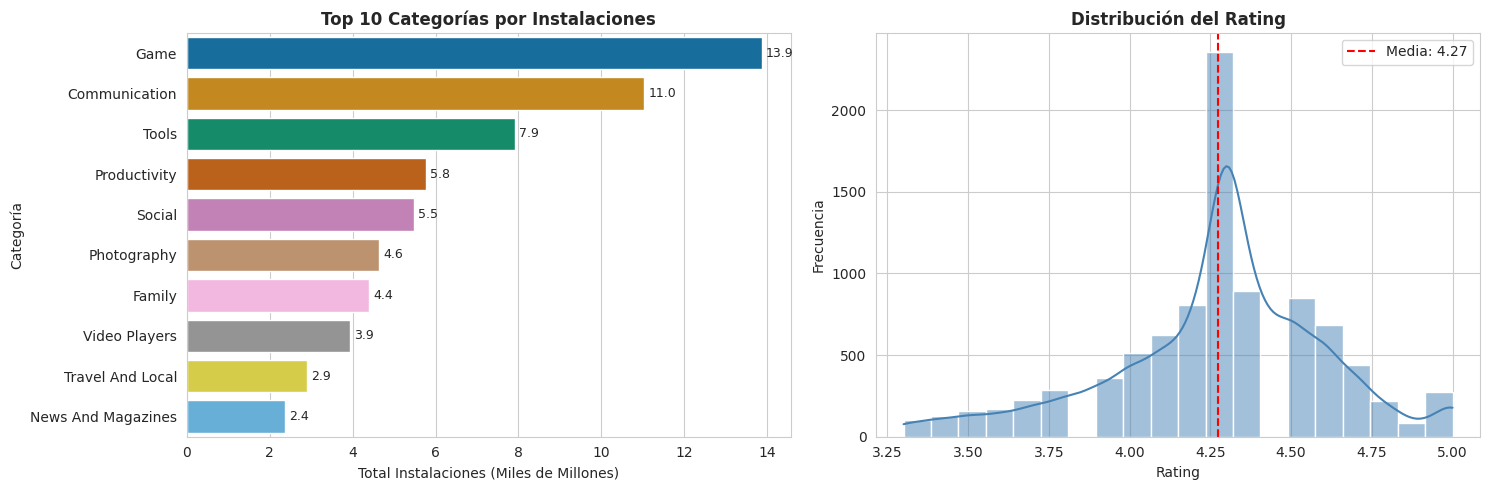

In [105]:
# ============================================================
# Reportes y Visualizaciones
# 2 gráficos: categorías con más descargas + distribución rating
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Gráfico 1: Top 10 categorías por instalaciones ───────────
top10 = (
    df.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
# ✅ FIX: dividir por 1.000.000.000 para mostrar en miles de millones
top10_billones = top10 / 1_000_000_000

sns.barplot(x=top10_billones.values, y=top10_billones.index, ax=axes[0], palette='colorblind')
axes[0].set_title('Top 10 Categorías por Instalaciones', fontweight='bold')
axes[0].set_xlabel('Total Instalaciones (Miles de Millones)')  # ✅ etiqueta actualizada
axes[0].set_ylabel('Categoría')

# ✅ FIX: agregar el valor exacto al final de cada barra
for i, v in enumerate(top10_billones.values):
    axes[0].text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=9)

# ── Gráfico 2: Distribución del Rating ───────────────────────
sns.histplot(df['Rating'], bins=20, kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(df['Rating'].mean(), color='red', linestyle='--',
                label=f"Media: {df['Rating'].mean():.2f}")
axes[1].set_title('Distribución del Rating', fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.savefig('visualizaciones.png', dpi=150)
plt.show()

# 10.- Transformaciones Avanzadas

In [106]:
# ============================================================
# Transformaciones Avanzadas
# pivot_table, melt, vectorización np.where, broadcasting NumPy
# ============================================================

# ── 10.1 pivot_table ────
# Tabla dinámica: rating promedio según categoría y tipo de app
  # pivot_table es equivalente a una tabla dinámica de Excel.
    # Permite cruzar dos variables categóricas y agregar una numérica.
tabla_pivot = df.pivot_table(
    index='Category',
    columns='Type',
    values='Rating',
    aggfunc='mean'
).round(2)
tabla_pivot = tabla_pivot.fillna(tabla_pivot.mean()).round(2)

print("=== pivot_table: Rating promedio por Categoría y Tipo ===")
print(tabla_pivot.head(5).to_string())
# → Permite comparar directamente el rating de apps Free vs Paid
  #   dentro de cada categoría.


=== pivot_table: Rating promedio por Categoría y Tipo ===
Type                 Free  Paid
Category                       
Art And Design       4.36  4.73
Auto And Vehicles    4.30  4.40
Beauty               4.31  4.38
Books And Reference  4.35  4.34
Business             4.29  4.25


In [107]:
# ── 10.2 melt: Transformar de formato ancho a largo ────────────
  # melt hace el proceso inverso al pivot: pasa columnas a filas.
    # Es útil para graficar múltiples métricas en un mismo eje.

# 1. Seleccionamos las métricas numéricas del df actual (primeras 10 filas)
df_metricas = df[['Rating', 'Reviews', 'Installs']].head(10).copy()

# 2. Rescatamos los nombres de las apps desde el df_original usando los índices
df_metricas['App'] = df_original.loc[df_metricas.index, 'App']

# 3. Aplicamos melt
df_largo = df_metricas.melt(
    id_vars='App',                            # columna que se mantiene como ID
    value_vars=['Rating', 'Reviews', 'Installs'],  # columnas que se transforman a filas
    var_name='Metrica',                       # nombre de la columna de etiquetas
    value_name='Valor'                        # nombre de la columna de valores
)

print("\n=== melt: Formato largo (primeras 5 filas) ===")
print(df_largo.head(5).to_string(index=False))


=== melt: Formato largo (primeras 5 filas) ===
                                               App Metrica  Valor
    Photo Editor & Candy Camera & Grid & ScrapBook  Rating    4.1
                               Coloring book moana  Rating    3.9
U Launcher Lite – FREE Live Cool Themes, Hide Apps  Rating    4.7
                             Sketch - Draw & Paint  Rating    4.5
             Pixel Draw - Number Art Coloring Book  Rating    4.3


In [108]:
import numpy as np
# ── 10.3 np.where: Vectorización (equivale a IF anidado) ───────
  # Clasifica apps según instalaciones sin usar loops
    # Es más eficiente que apply() porque opera sobre arrays
df['Popularidad'] = np.where(df['Installs'] >= 1_000_000, 'Alta', 'Baja')
print("\n=== np.where: Popularidad ===")
print(df['Popularidad'].value_counts())




=== np.where: Popularidad ===
Popularidad
Baja    5803
Alta    3354
Name: count, dtype: int64


In [109]:
import numpy as np

# ── 10.4 Broadcasting NumPy: Score compuesto ───────────────────
# Broadcasting permite aplicar operaciones matemáticas entre arrays
  # Operación matemática directa entre dos arrays NumPy
    # Combina rating e instalaciones en un score único
df['Score'] = df['Rating'].to_numpy() * np.log1p(df['Installs'].to_numpy()).round(1)

print("\n=== Broadcasting: Score compuesto ===")

# Seleccionamos las métricas a mostrar (solo las primeras 3 filas)
df_mostrar = df[['Rating', 'Score']].head(3).copy()

# Rescatamos el nombre de la App desde df_original usando el índice
df_mostrar['App'] = df_original.loc[df_mostrar.index, 'App']

# Imprimimos reordenando las columnas para que 'App' salga primero
print(df_mostrar[['App', 'Rating', 'Score']].to_string(index=False))


=== Broadcasting: Score compuesto ===
                                               App  Rating  Score
    Photo Editor & Candy Camera & Grid & ScrapBook     4.1  37.72
                               Coloring book moana     3.9  51.09
U Launcher Lite – FREE Live Cool Themes, Hide Apps     4.7  72.38


In [110]:
# Eliminamos columnas auxiliares creadas en las secciones 11 y 12
# antes de aplicar el One-Hot Encoding.
df.drop(columns=['Popularidad', 'Score'], inplace=True, errors='ignore')

# 11- Preparación del Dataset para Machine Learning
* **Baja Cardinalidad:** Aplicamos One-Hot Encoding a `Category`, `Type` y `Content Rating` (convirtiendo los booleanos a 1 y 0).

In [111]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np

# ============================================================
# PASO 9: One-Hot Encoding (Usando Scikit-Learn)
# ============================================================

# 1. Instanciamos el codificador
# sparse_output=False para que nos devuelva un array normal y no una matriz dispersa
# drop='first' para evitar la redundancia (multicolinealidad)
encoder = OneHotEncoder(sparse_output=False, drop='first')

# 2. Definimos las columnas a las que aplicaremos One-Hot Encoding
columnas_olhe = ['Category', 'Type', 'Content Rating']

# 3. Ajustamos y transformamos los datos
nombres_nuevas_columnas = []
datos_transformados = encoder.fit_transform(df[columnas_olhe])

# 4. Obtenemos los nombres de las nuevas columnas generadas
nombres_nuevas_columnas = encoder.get_feature_names_out(columnas_olhe)

# 5. Creamos un DataFrame con los nuevos datos y lo unimos al original
df_encoded = pd.DataFrame(datos_transformados, columns=nombres_nuevas_columnas, index=df.index)

# Concatenamos y eliminamos las columnas originales de texto
df = pd.concat([df, df_encoded], axis=1)
df.drop(columns=columnas_olhe, inplace=True)

# Verificamos que ahora todo sea numérico
print("=======================================================")
print("      DATASET TRANSFORMADO CON ONE-HOT ENCODING        ")
print("=======================================================")
print(f"Nuevas columnas creadas: {len(nombres_nuevas_columnas)}")
print(f"Total columnas finales: {df.shape[1]}")
print("\nTipos de datos en el DataFrame:")
print(df.dtypes.value_counts())

      DATASET TRANSFORMADO CON ONE-HOT ENCODING        
Nuevas columnas creadas: 38
Total columnas finales: 46

Tipos de datos en el DataFrame:
float64           44
datetime64[ns]     1
int64              1
Name: count, dtype: int64


# 12.- Verificación Final del Dataset
Comprobamos la estructura final después de todo el pipeline de limpieza para asegurar que los datos estén listos para el análisis.

In [112]:
# Validamos la info general y la estadística descriptiva final
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9157 entries, 0 to 10840
Data columns (total 46 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Rating                        9157 non-null   float64       
 1   Reviews                       9157 non-null   float64       
 2   Size                          9157 non-null   float64       
 3   Installs                      9157 non-null   float64       
 4   Price                         9157 non-null   float64       
 5   Last Updated                  9157 non-null   datetime64[ns]
 6   Android Ver                   9157 non-null   float64       
 7   Genres_Freq                   9157 non-null   int64         
 8   Category_Auto And Vehicles    9157 non-null   float64       
 9   Category_Beauty               9157 non-null   float64       
 10  Category_Books And Reference  9157 non-null   float64       
 11  Category_Business             9157

# 13. Verificación de Integridad

In [115]:
import pandas as pd

# ============================================================
# 13.- Verificación de Integridad
# IMPORTANTE: esta sección corre DESPUÉS del One-Hot Encoding,
# por eso 'Type' ya no existe como texto. Usamos 'Type_Paid'.
#   1. auditar_dataset      → métricas de calidad por columna
#   2. validar_rangos       → rangos válidos en columnas clave
#   3. verificar_consistencia → cruza columnas para detectar errores
# ============================================================


def auditar_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Revisa cada columna del dataset y genera un reporte de calidad.

    Para cada columna informa: tipo de dato, cantidad de nulos,
    porcentaje de nulos, duplicados, valores únicos y un estado
    visual (OK o Con nulos).

    Args:
        df: El DataFrame a auditar.

    Returns:
        Un DataFrame con una fila por columna y sus métricas de calidad.
        Las columnas OHE binarias se agrupan en un resumen al final.
    """
    # Separamos columnas OHE (binarias 0/1) de las columnas reales
    # para no generar un reporte de 50+ filas ilegible.
    cols_ohe    = [c for c in df.columns if df[c].nunique() <= 2 and df[c].dtype in ['uint8', 'int64', 'float64']
                   and set(df[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
    cols_reales = [c for c in df.columns if c not in cols_ohe]

    reporte = []
    for col in cols_reales:
        total      = len(df)
        nulos      = df[col].isnull().sum()
        pct_nulos  = round(nulos / total * 100, 2)
        duplicados = df[col].duplicated().sum()
        unicos     = df[col].nunique()
        tipo       = str(df[col].dtype)

        reporte.append({
            'Columna'   : col,
            'Tipo'      : tipo,
            'Nulos'     : nulos,
            '% Nulos'   : pct_nulos,
            'Duplicados': duplicados,
            'Únicos'    : unicos,
            'Estado'    : '✅ OK' if nulos == 0 else '⚠️ Con nulos'
        })

    # Agrupamos las columnas OHE en una sola fila resumen
    if cols_ohe:
        nulos_ohe = df[cols_ohe].isnull().sum().sum()
        reporte.append({
            'Columna'   : f'[{len(cols_ohe)} columnas OHE binarias]',
            'Tipo'      : 'uint8/int',
            'Nulos'     : nulos_ohe,
            '% Nulos'   : round(nulos_ohe / (len(df) * len(cols_ohe)) * 100, 2),
            'Duplicados': '-',
            'Únicos'    : '0 y 1',
            'Estado'    : '✅ OK' if nulos_ohe == 0 else '⚠️ Con nulos'
        })

    return pd.DataFrame(reporte)


def validar_rangos(df: pd.DataFrame) -> pd.DataFrame:
    """Verifica que las columnas numéricas clave tengan valores válidos.

    Aplica reglas de negocio: Rating entre 1 y 5, Price, Installs
    y Reviews no pueden ser negativos.

    Args:
        df: El DataFrame a validar.

    Returns:
        Un DataFrame con el resultado de cada regla.
    """
    # CORRECCIÓN: el comentario no puede tener espacio extra antes — causa IndentationError
    # Cada regla es una tupla: (columna, condición booleana, descripción)
    reglas = [
        ('Rating',   df['Rating'].between(1, 5),  'Rating entre 1 y 5'),
        ('Price',    df['Price'] >= 0,             'Price no negativo'),
        ('Installs', df['Installs'] >= 0,          'Installs no negativo'),
        ('Reviews',  df['Reviews'] >= 0,           'Reviews no negativo'),
    ]

    resultados = []
    for col, condicion, descripcion in reglas:
        total     = len(df)
        cumple    = condicion.sum()
        no_cumple = total - cumple
        resultados.append({
            'Regla'        : descripcion,
            'Total Filas'  : total,
            'Cumplen'      : cumple,
            'Violan'       : no_cumple,
            'Cumplimiento' : f"{round(cumple / total * 100, 2)}%",
            'Estado'       : '✅ PASS' if no_cumple == 0 else '❌ FAIL'
        })
    return pd.DataFrame(resultados)


def verificar_consistencia(df: pd.DataFrame) -> pd.DataFrame:
    """Detecta apps marcadas como gratuitas pero con precio mayor a 0.

    CORRECCIÓN: después del One-Hot Encoding, la columna 'Type' ya no
    existe como texto. El OHE la convirtió en columnas binarias.
    Detectamos el formato automáticamente para no depender del orden
    de ejecución de las celdas.

    Regla: una app Free debe tener Price == 0.

    Args:
        df: El DataFrame a verificar (puede ser pre o post OHE).

    Returns:
        Un DataFrame con las filas inconsistentes. Vacío si no hay errores.
    """
    # Detectamos en qué formato está la columna Type
    if 'Type' in df.columns:
        # Antes del OHE: Type es texto ('Free' / 'Paid')
        mask_free = df['Type'] == 'Free'

    elif 'Type_Paid' in df.columns:
        # Después del OHE con drop_first=True:
        # Type_Paid = 0 → Free | Type_Paid = 1 → Paid
        mask_free = df['Type_Paid'] == 0

    elif 'Type_Free' in df.columns:
        # Después del OHE sin drop_first:
        # Type_Free = 1 → Free | Type_Free = 0 → Paid
        mask_free = df['Type_Free'] == 1

    else:
        # No se encontró ninguna variante de la columna Type
        print("⚠️  Columna 'Type' no encontrada en ningún formato.")
        return pd.DataFrame(columns=['App', 'Price'])

    # Aplicamos la regla: Free con Price > 0 es inconsistente
    inconsistentes = df[mask_free & (df['Price'] > 0)].copy()

    if not inconsistentes.empty:
        # Rescatamos el nombre de la app desde el dataset original
        inconsistentes['App'] = df_original.loc[inconsistentes.index, 'App']
        return inconsistentes[['App', 'Price']]

    # Retornamos DataFrame vacío tipado (no lanza error al hacer len())
    return pd.DataFrame(columns=['App', 'Price'])


# ── Ejecutar las tres verificaciones ─────────────────────────
print("=" * 55)
print("  AUDITORÍA DE INTEGRIDAD — Google Play Store")
print("=" * 55)

# 1. Reporte columna por columna (OHE agrupado en 1 fila)
reporte_auditoria = auditar_dataset(df)
print("\n📋 REPORTE POR COLUMNA:")
print(reporte_auditoria.to_string(index=False))

# 2. Validación de rangos
reporte_rangos = validar_rangos(df)
print("\n🔍 VALIDACIÓN DE RANGOS:")
print(reporte_rangos.to_string(index=False))

# 3. Consistencia lógica (funciona con o sin OHE aplicado)
inconsistentes = verificar_consistencia(df)
print(f"\n⚖️  CONSISTENCIA LÓGICA (Free con Price > 0):")
if len(inconsistentes) == 0:
    print("  ✅ Sin inconsistencias detectadas.")
else:
    print(f"  ❌ {len(inconsistentes)} casos inconsistentes:")
    print(inconsistentes.to_string(index=False))

# 4. Score general de integridad
checks_ok    = (reporte_rangos['Estado'] == '✅ PASS').sum()
total_checks = len(reporte_rangos)
nulos_total  = reporte_auditoria['Nulos'].sum()
score        = round(checks_ok / total_checks * 100, 1)

print(f"\n📊 SCORE GENERAL DE INTEGRIDAD:")
print(f"  Reglas de rango aprobadas  : {checks_ok}/{total_checks}")
print(f"  Nulos totales en el dataset: {nulos_total}")
print(f"  Score de integridad        : {score}%")

  AUDITORÍA DE INTEGRIDAD — Google Play Store

📋 REPORTE POR COLUMNA:
                   Columna           Tipo  Nulos  % Nulos Duplicados Únicos Estado
                    Rating        float64      0      0.0       9139     18   ✅ OK
                   Reviews        float64      0      0.0       3933   5224   ✅ OK
                      Size        float64      0      0.0       8720    437   ✅ OK
                  Installs        float64      0      0.0       9137     20   ✅ OK
                     Price        float64      0      0.0       9067     90   ✅ OK
              Last Updated datetime64[ns]      0      0.0       7810   1347   ✅ OK
               Android Ver        float64      0      0.0       9136     21   ✅ OK
               Genres_Freq          int64      0      0.0       9112     45   ✅ OK
[38 columnas OHE binarias]      uint8/int      0      0.0          -  0 y 1   ✅ OK

🔍 VALIDACIÓN DE RANGOS:
               Regla  Total Filas  Cumplen  Violan Cumplimiento Estado
  Ra